Accuracy: 1.00

Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        19
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        14

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



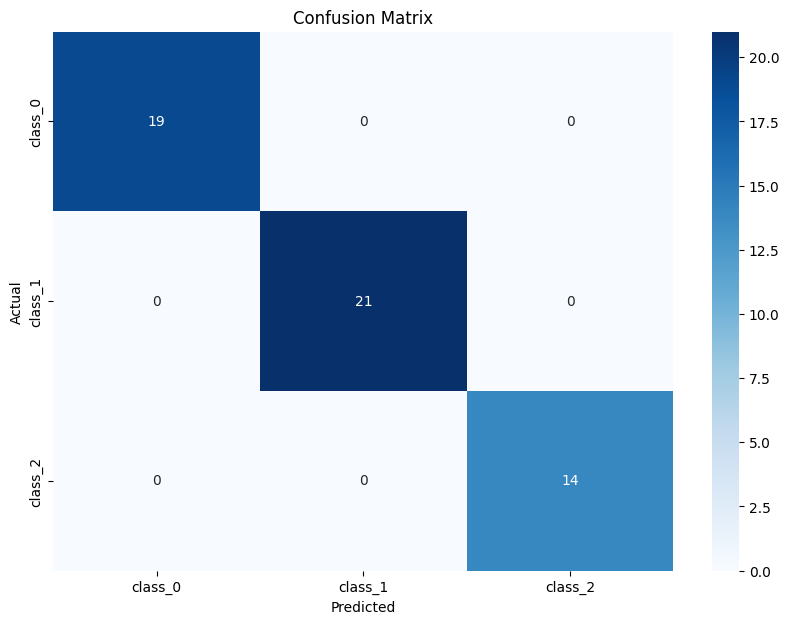


Feature Importances: 
                         Feature  Importance
9                color_intensity    0.180198
6                     flavanoids    0.165947
0                        alcohol    0.142041
12                       proline    0.126080
11  od280/od315_of_diluted_wines    0.096032
10                           hue    0.085966
5                  total_phenols    0.059758
4                      magnesium    0.034673
3              alcalinity_of_ash    0.033211
8                proanthocyanins    0.029778
1                     malic_acid    0.028976
2                            ash    0.011859
7           nonflavanoid_phenols    0.005480


In [3]:
# Paso 1: Importar las Librerías Necesarias
import numpy as np
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Paso 2: Cargar el Conjunto de Datos
data = load_wine()
x = data.data
y = data.target

# Paso 3: Dividir el Conjunto de Datos en Entrenamiento y Prueba
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

# Paso 4: Entrenar el Modelo Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(x_train, y_train)

# Paso 5: Realizar Predicciones
y_pred = model.predict(x_test)

# Paso 6: Evaluar el Modelo
accuracy = accuracy_score (y_test, y_pred)
print (f'Accuracy: {accuracy:.2f}')


# Generar el Reporte de Clasificación
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

# Generar la Matriz de Confusión
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=data.target_names, yticklabels=data.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Mostrar Importancia de Características
importances = model.feature_importances_
feature_names = data.feature_names
df_importances = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
df_importances = df_importances.sort_values(by='Importance', ascending=False)
print("\nFeature Importances: ")
print(df_importances)